In [4]:
import numpy as np
import pandas as pd

original_matrix = pd.read_csv("prs_conditioanlOR_matrix_260217_rootcode_qc.csv")
original_matrix = original_matrix.set_index("trait")
rank_matrix = pd.read_csv("prs_conditionalOR_matrix_260217_rootcode_rankmatrix.csv")
rank_matrix = rank_matrix.set_index("trait")
metainfo = pd.read_csv("../../disease_preprocess/pgs_metadata_260217.csv")
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first").set_index("PGS_ID")

### Histogram of the Best Performing PGS 

C62 98.00287065596328
C73 94.18698932587256
E11 95.52470071776044
I21 94.87900268779612
I50 97.23665260611683
I71 98.50610426791644
M08 91.45693011952712


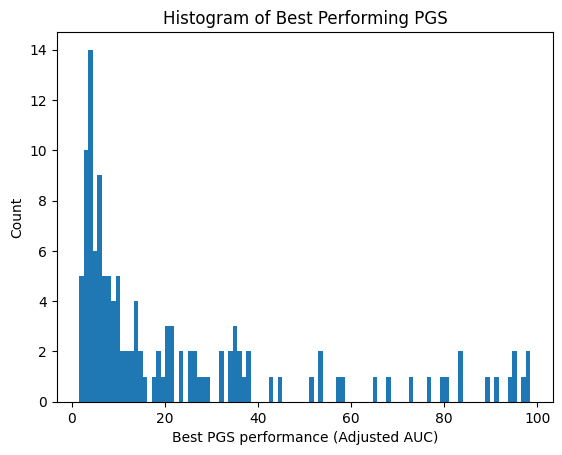

In [8]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(max(matrix.loc[trait]))
    if max(matrix.loc[trait]) > 90:
        print(trait, max(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing PGS")
plt.show()

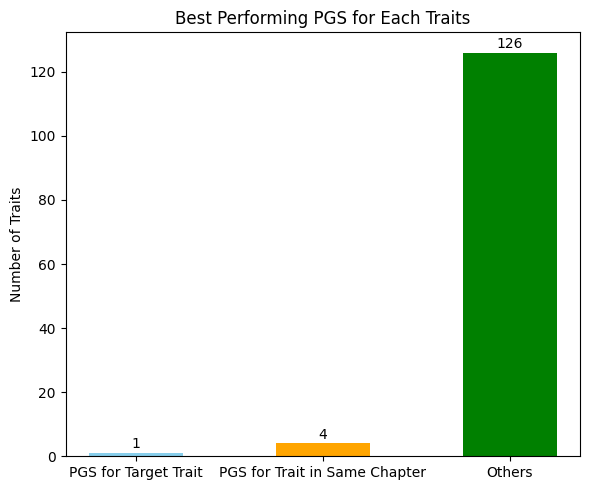

In [9]:
self_pgs_count = 0
same_chap_count = 0
others = 0
for trait in rank_matrix.index:

    best_pgs = rank_matrix.loc[trait].iloc[0]
    chapter = str(trait[0])

    if trait in best_pgs.split("__")[0].split("+"):
        self_pgs_count += 1
        continue
    
    elif any(chapter in item for item in best_pgs.split("__")[0].split("+")):
        same_chap_count += 1
    
    else:
        others += 1

counts = [self_pgs_count, same_chap_count, others]
labels = ["PGS for Target Trait", "PGS for Trait in Same Chapter", "Others"]
x = [0, 3, 6] 

plt.figure(figsize=(6,5))
plt.bar(x, counts, color=["skyblue", "orange", "green"], width=1.5)
plt.xticks(x, labels)
plt.ylabel("Number of Traits")
plt.title("Best Performing PGS for Each Traits")
for i, count in enumerate(counts):
    plt.text(x[i], count + 0.5, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

F43
I49
L28
R94


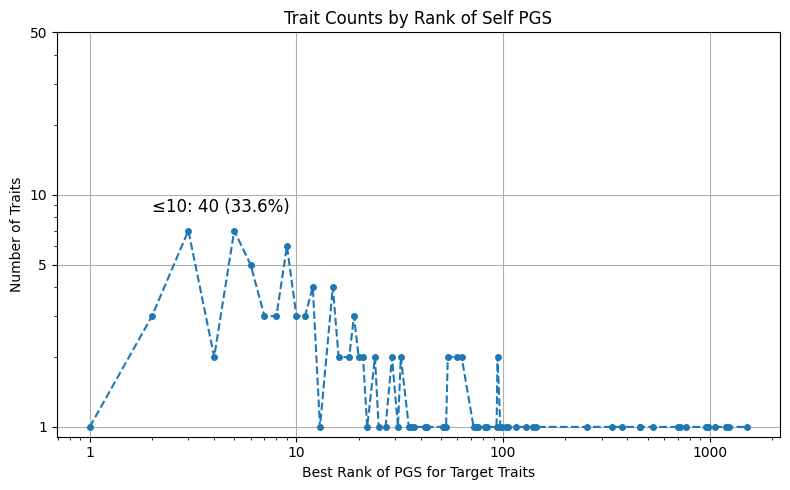

In [11]:
from collections import Counter

best_self_pgs_rank = []
for trait in rank_matrix.index:

    for idx, m in enumerate(rank_matrix.loc[trait]):
        
        if trait in m.split("__")[0].split("+"):
            best_self_pgs_rank.append(idx + 1)
            if idx > 1000:
                print(trait)
            break


rank_counts = Counter(best_self_pgs_rank)
ranks = sorted(rank_counts.keys())
counts = [rank_counts[r] for r in ranks]

total_traits = len(best_self_pgs_rank)
num_top10 = sum(
    count for r, count in rank_counts.items() if r <= 10
)
ratio = num_top10 / total_traits

plt.figure(figsize=(8,5))
plt.plot(ranks, counts, '--', marker='o', markersize=4)

plt.text(
    2, max(counts)*1.2,
    f"≤10: {num_top10} ({ratio:.1%})",
    fontsize=12
)

plt.xlabel("Best Rank of PGS for Target Traits")
plt.ylabel("Number of Traits")
plt.title("Trait Counts by Rank of Self PGS")
plt.xscale('log')
plt.yscale('log')
plt.xticks([1, 10, 100, 1000], ["1", "10", "100", "1000"])
plt.yticks([1, 5, 10, 50], ["1", "5", "10", "50"])
plt.grid(0.6)
plt.tight_layout()
plt.show()

### Histogram of the Worse Performing PGS 

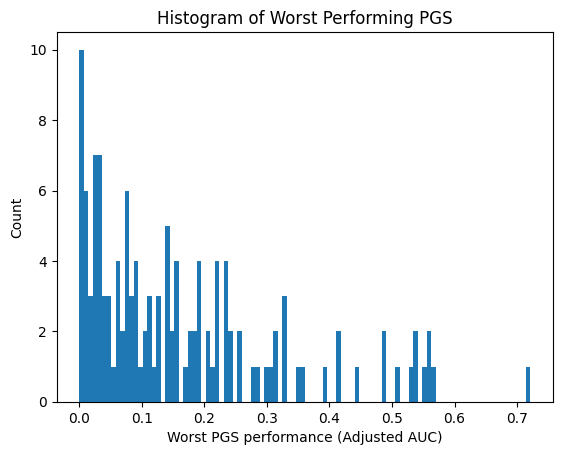

In [13]:
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(min(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing PGS")
plt.show()

### Histogram of the PRS Performing Range

C62 98.00269474685508
C73 94.04269068337564
E11 95.5188482215571
I21 94.8495495379766
I50 97.22561248983676
I71 98.42210996275618
M08 91.45455088487448


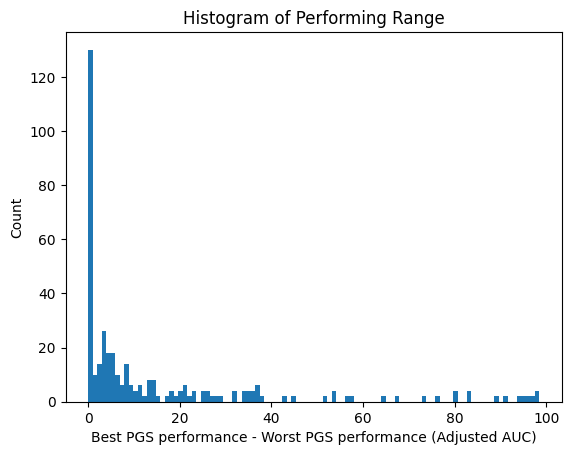

In [15]:
matrix = original_matrix.copy()
for trait in matrix.index:
    temp = max(matrix.loc[trait]) - min(matrix.loc[trait])
    max_list.append(temp)
    if temp > 90:
        print(trait, temp)
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

In [17]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.nanmin(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 90]
print("Traits with performance range bigget than 90: ", large_diff_traits)

Traits with performance range bigget than 90:  ['C62', 'C73', 'E11', 'I21', 'I50', 'I71', 'M08']


### Histogram of Range Between Median and the Best

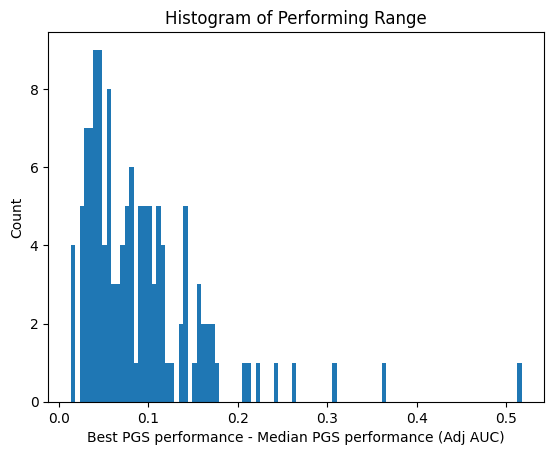

In [8]:
matrix = original_matrix.copy()
max_list = [max(matrix.loc[trait]) - np.median(matrix.loc[trait]) for trait in matrix.index]
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Median PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show() 

In [9]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.median(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.3]
print("Traits with performance range bigget than 0.3: ", large_diff_traits)

Traits with performance range bigget than 0.3:  ['C62', 'C73', 'O14']


### Correlation: Number of Variants - Performance

In [18]:
def add_significance(ax, x1, x2, y, p):
    h = y * 0.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5)
    
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = "**"
    elif p < 0.05:
        text = "*"
    else:
        text = "ns"
    
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

In [19]:
num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_variant"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

Global p: 6.244153929780466e-05


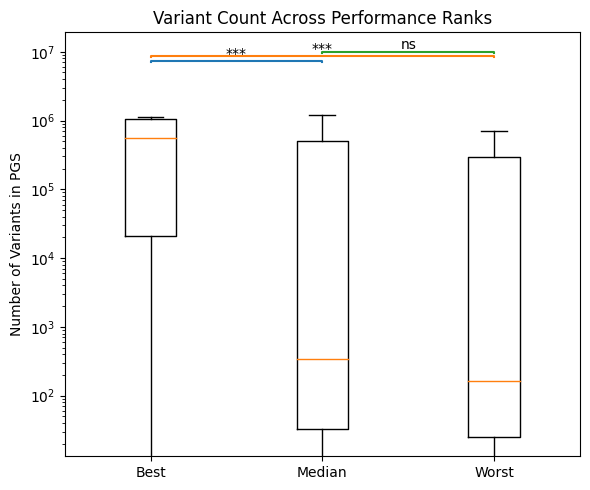

In [20]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_yscale("log")
ax.set_ylabel("Number of Variants in PGS")
ax.set_title("Variant Count Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, y_max*1.1, p1)
add_significance(ax, 1, 3, y_max*1.3, p2)
add_significance(ax, 2, 3, y_max*1.5, p3)

plt.tight_layout()
plt.show()

### Correlation: Date Release - Performance

In [21]:
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        release_date = pd.to_datetime(metainfo.loc[temp_id]["date_release"])
        days_diff = (today - release_date).days

        days_list.append(days_diff)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.37433665077531064


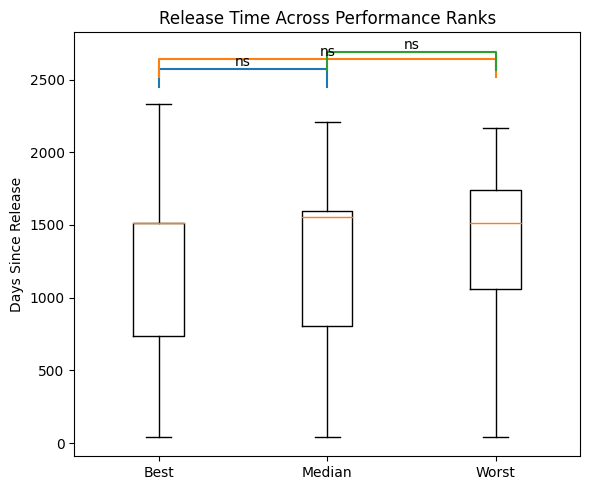

In [22]:
import matplotlib.pyplot as plt

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Days Since Release")
ax.set_title("Release Time Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, y_max*1.05, p1)
add_significance(ax, 1, 3, y_max*1.08, p2)
add_significance(ax, 2, 3, y_max*1.10, p3)

plt.tight_layout()
plt.show()

### Correlation: Reported Performance - Performance

#### Odds Ratio

In [23]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Odds Ratio":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan

In [24]:
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.31152227883234584


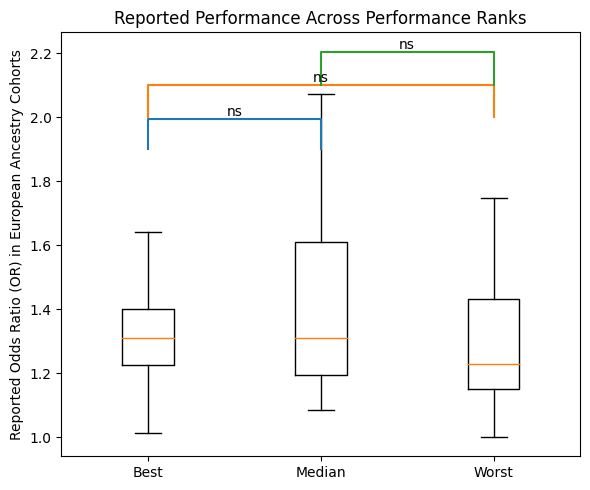

In [25]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Reported Odds Ratio (OR) in European Ancestry Cohorts")
ax.set_title("Reported Performance Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, 1.9, p1)
add_significance(ax, 1, 3, 2.0, p2)
add_significance(ax, 2, 3, 2.1, p3)

plt.tight_layout()
plt.show()

#### Adjusted AUC

In [18]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Area Under the Receiver-Operating Characteristic Curve":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan
    
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.6044870643077854


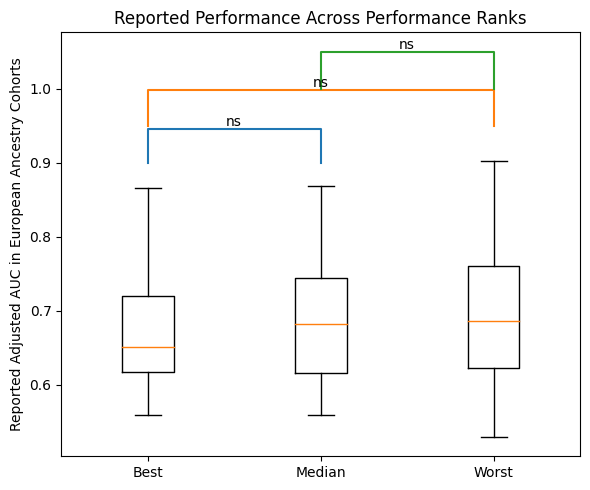

In [22]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Reported Adjusted AUC in European Ancestry Cohorts")
ax.set_title("Reported Performance Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, 0.90, p1)
add_significance(ax, 1, 3, 0.95, p2)
add_significance(ax, 2, 3, 1.00, p3)

plt.tight_layout()
plt.show()

#### Beta

In [27]:
print(np.unique(metainfo["eval_metrics"]))

["['Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Odds Ratio', 'Hazard Ratio']"
 "['Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating Characteristic Curve', 'Area Under the Receiver-Operating 

In [28]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if metric not in ["partial R²", "partial-R2"]:
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan
    
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [30]:
print(len(num_variant_best))

1


Global p: 0.36787944117144245


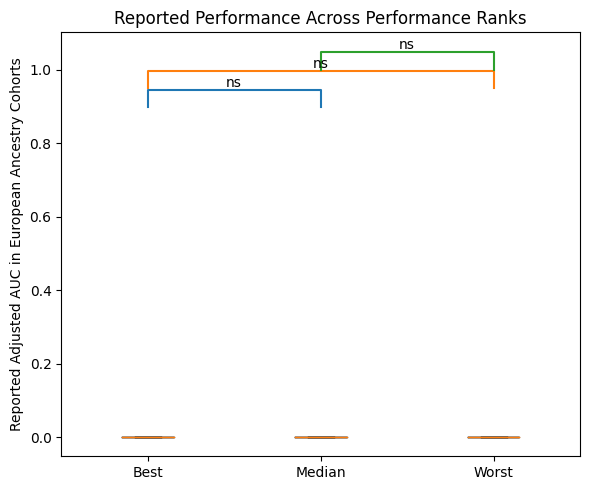

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Reported Adjusted AUC in European Ancestry Cohorts")
ax.set_title("Reported Performance Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, 0.90, p1)
add_significance(ax, 1, 3, 0.95, p2)
add_significance(ax, 2, 3, 1.00, p3)

plt.tight_layout()
plt.show()